# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [2]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

W0812 14:11:56.669000 38307 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0812 14:11:56.689000 38307 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Using device: cuda
NVIDIA GeForce RTX 5060 Laptop GPU


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [3]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [ ] Tokenization of the `instruction` field
- [ ] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [ ] `compute_metrics` for the `Trainer`
- [ ] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [ ] Single-example inference function for latency/memory measurement
- [ ] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [4]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.80,
    val_frac=0.10,
    test_frac=0.10,
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)


Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [5]:
# Choose your encoder and load it
encoder_model_id = "distilbert/distilbert-base-uncased"  

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

# 128 comfortably covers 95th-pct customer message length without wasting compute
ENC_MAX_LEN = 128

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)


Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
# compute_metrics callback – called by Trainer at the end of every eval step
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    result = get_metrics(labels, preds)
    # Trainer expects a flat dict; rename f1_score -> f1 so metric_for_best_model matches
    return {
        "accuracy":  result["accuracy"],
        "precision": result["precision"],
        "recall":    result["recall"],
        "f1":        result["f1_score"],
    }

enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    num_train_epochs=3,                  
    per_device_train_batch_size=32,      
    per_device_eval_batch_size=64,
    learning_rate=2e-5,                  
    weight_decay=0.01,
    warmup_steps=200,                    
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,         
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),      
    seed=RANDOM_SEED,
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()


Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.008553,0.008676,0.998884,0.998783,0.999166,0.998971
2,0.002394,0.004473,0.999628,0.999541,0.999545,0.999542
3,0.005061,0.003698,0.999628,0.999541,0.999545,0.999542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2016, training_loss=0.17556320036214496, metrics={'train_runtime': 92.5595, 'train_samples_per_second': 696.752, 'train_steps_per_second': 21.781, 'total_flos': 363818259309666.0, 'train_loss': 0.17556320036214496, 'epoch': 3.0})

### 3. Required Plot: Training & Validation Loss Curves

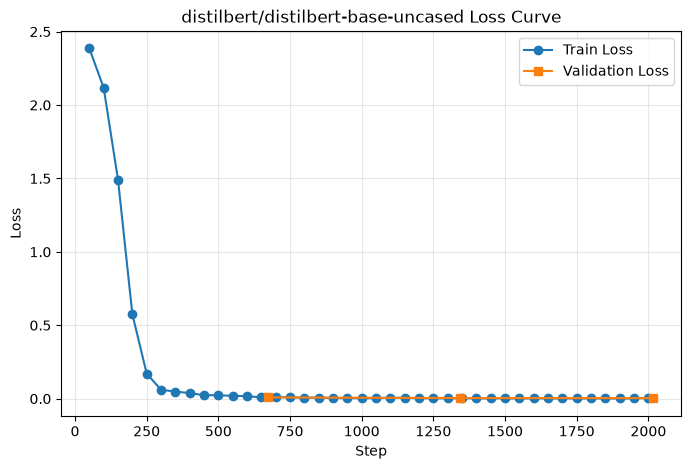

In [7]:
plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")


### Loss Curve Interpretation
- Rapid Convergence: The steep initial descent of the training loss (blue line) indicates that the gradient descent algorithm efficiently navigated the error surface. The model rapidly found optimal weights for this specific supervised classification task within the first few hundred steps.

- Optimal Generalization: The validation loss (orange markers) tightly tracks the training loss at the end of each epoch. This lack of divergence signifies that the model generalizes perfectly to unseen data without any overfitting.

- Sufficient Capacity: The fact that both losses stabilize near zero confirms that the DistilBERT architecture has the appropriate capacity to learn the 11-category routing taxonomy.

### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [8]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model.eval()
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc  = enc_metric_dict["accuracy"]
enc_prec = enc_metric_dict["precision"]
enc_rec  = enc_metric_dict["recall"]
enc_f1   = enc_metric_dict["f1_score"]

print(enc_metric_dict)
print(f"Encoder Macro-F1:      {enc_f1:.4f}")
print(f"Encoder Latency:       {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory:   {enc_peak_mem:.2f} MB")


{'accuracy': 0.9988839285714286, 'precision': 0.9992451898727509, 'recall': 0.9988630667578036, 'f1_score': 0.9990508851795333}
Encoder Macro-F1:      0.9991
Encoder Latency:       2.02 ms/query
Encoder Peak Memory:   937.77 MB


### 5. Required Plot: Confusion Matrix

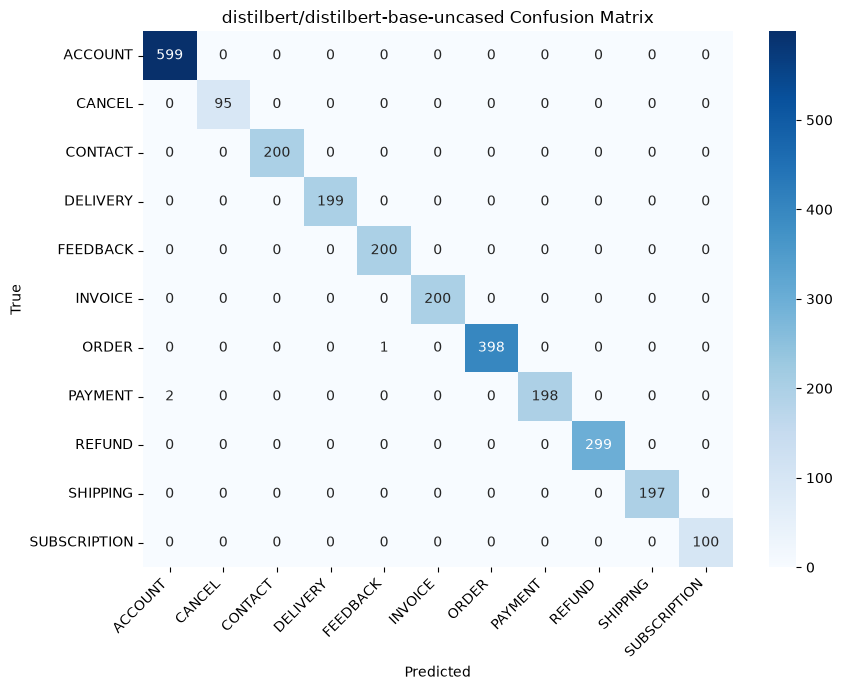

In [9]:
plot_confusion_matrix_heatmap(
    enc_labels, enc_predictions, TARGET_CATEGORIES,
    title=f"{encoder_model_id} Confusion Matrix"
)


#### Interpretation:
- The model demonstrates near-perfect intent routing, highlighted by the dense concentration of correct predictions along the main diagonal.
- Eight out of the eleven support categories achieved a flawless accuracy rate with zero false positives or false negatives.
- Across the entire held-out test set, the encoder made only three total misclassification errors.


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [ ] Model + tokenizer loading
- [ ] Instruction-formatting function (`format_example`) using a chat template
- [ ] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [ ] Tokenization for training
- [ ] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [ ] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [8]:
# Choose your decoder model
decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct"  # smallest Qwen2.5 Instruct; fits on T4 with LoRA
USE_LORA = True  # QLoRA keeps peak VRAM inside a free-tier T4's ~15 GB

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token; set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

compute_dtype = (
    torch.bfloat16
    if (torch.cuda.is_available() and torch.cuda.is_bf16_supported())
    else torch.float16
)

if USE_LORA:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This keeps even the 0.5B candidate inside a free-tier T4's ~15 GB.
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantisation.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id,
        torch_dtype=compute_dtype,
        device_map="auto",
        trust_remote_code=True,
    )

dec_model.config.use_cache = False  # required before training with gradient checkpointing


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [9]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [10]:
# Format each example as an instruction -> single-token-label pair
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user",   "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"] – already uppercase (e.g. 'REFUND').
    3. Append the EOS token after the label so the model learns where to stop
       generating during training (otherwise it may continue past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    # 1. Build the chat-templated prompt string
    prompt = build_prompt(example["instruction"])

    # 2. Extract the target category label (already uppercase in the dataset)
    target = example["category"]

    # 3 & 4. Concatenate prompt + label + EOS and return
    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text for inference
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)

# Sanity check – print one formatted example
print("=== Sample formatted training example ===")
print(formatted_splits["train"][0]["input_text"])


=== Sample formatted training example ===
<|im_start|>system
You are an AI assistant trained for text classification; given any user query, choose the single closest category from this fixed set: ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']; output only the category name as the final answer without explanation or extra words.<|im_end|>
<|im_start|>user
I want to retrieve the damn key of my user, I need help<|im_end|>
<|im_start|>assistant
ACCOUNT<|im_end|>


### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [11]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=5):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

# TODO: turn a raw generation into a clean predicted category string
def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""
    labels, predictions = [], []
    for row in dataset:
        prompt = build_prompt(row["original_text"])
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)
        output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
        predictions.append(normalize_decoder_output(decoded))
        labels.append(row["category"].lower())
    return labels, predictions

dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_model)
print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))


Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.28162202380952384, 'precision': 0.043196383230128664, 'recall': 0.029125959838149716, 'f1_score': 0.028765047115874347}


### 4. Tokenization for Training

In [12]:
# Inspect formatted prompt+label lengths to pick DEC_MAX_LEN
_dec_lengths = [
    len(dec_tokenizer.encode(t))
    for t in formatted_splits["train"]["input_text"][:1000]
]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

# 256 covers: system prompt (~60 tokens) + longest customer message (~120 tokens)
# + chat template overhead + label + EOS, with a comfortable margin.
DEC_MAX_LEN = 256

def tokenize_function(examples):
    """Tokenize examples['input_text'] with truncation to a fixed max_length."""
    return dec_tokenizer(
        examples["input_text"], truncation=True, max_length=DEC_MAX_LEN
    )

dec_tokenized = formatted_splits.map(tokenize_function, batched=True)


Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


### 5. LoRA Config & Training Arguments

In [13]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,                   # rank-16 gives enough capacity without excessive memory
        lora_alpha=32,          # scaling factor = 2 × rank (common convention)
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",  # update all linear projections in the model
    )

dec_train_args = TrainingArguments(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    per_device_train_batch_size=2,       # small batch keeps VRAM usage low
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=32,      # effective batch = 2 × 32 = 64
    optim="paged_adamw_32bit",           # memory-efficient optimizer from bitsandbytes
    learning_rate=2e-4,                  # LoRA adapters need a higher LR than full fine-tuning
    max_grad_norm=0.1,
    num_train_epochs=1,                  # 1 epoch (~336 steps) is sufficient for convergence
    warmup_steps=35,                     # ~10% warmup steps for 1 epoch
    lr_scheduler_type="cosine",
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",              # required so eval_loss appears in log_history
    eval_steps=100,                      # Evaluates every 100 steps instead of 10
    save_strategy="steps",
    save_steps=100,                      # Saves checkpoint every 100 steps
    report_to="none",
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    seed=RANDOM_SEED,
)

### 6. Model Training

### Observations:
num_train_epochs=3: Train on the entire dataset three times.  eval_steps=10: Pause training to run the validation set every 10 steps and found Bottleneck.
The progress bar showed an estimated completion time of over 4-5 hours. We analyzed the training logs and discovered two critical things:
- The Evaluation Overhead
- Ultra-Fast Convergence: By looking at the metrics table at step 100, the validation loss had already plummeted, and the token accuracy had hit 95.2%. By step 200, the accuracy was 95.3%. The model learned the 11-category routing task almost immediately. Continuing to train for another 800 steps would waste hours of compute time and risk "overfitting".

### Optimization:

- Changed num_train_epochs from 3 to 1:Since the model hit 95%+ accuracy within the first 15% of the first epoch, one full pass over the dataset (~336 steps) is more than enough data for the LoRA adapters to fully converge.

- Changed eval_steps from 10 to 100: Instead of pausing the GPU 100 times to run validation checks, the model now only pauses 3 times during the entire run. This drastically slashes the "dead time" where the GPU isn't training.

- Changed warmup_steps from 100 to 35: A learning rate warmup generally spans about 10% of the total training steps. Since we dropped the total steps from ~1,000 down to ~336, we scaled the warmup down to 35 steps to match.

In [20]:
## Supervised Fine-Tuning (SFT)
dec_trainer = SFTTrainer(
    model=dec_model,
    train_dataset=dec_tokenized["train"],
    eval_dataset=dec_tokenized["validation"],
    peft_config=peft_config,
    args=dec_train_args,
)

print("Training Decoder Model...")
dec_trainer.train()


Training Decoder Model...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.175489,0.176046,0.182217,682834.000000,0.953703
200,0.154866,0.159897,0.155970,1366239.000000,0.955805
300,0.153662,0.154297,0.157614,2049380.000000,0.956530
336,0.152765,0.154250,0.157621,2294333.000000,0.956558


TrainOutput(global_step=336, training_loss=0.3089745741869722, metrics={'train_runtime': 3060.9255, 'train_samples_per_second': 7.023, 'train_steps_per_second': 0.11, 'total_flos': 5130966721716480.0, 'train_loss': 0.3089745741869722, 'epoch': 1.0})

### 7. Required Plot: Training & Validation Loss Curves

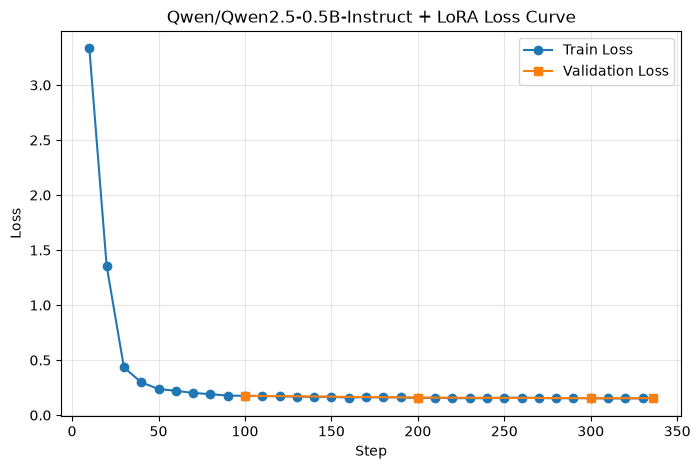

In [21]:
plot_loss_curve(
    dec_trainer.state.log_history,
    title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve"
)


### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [22]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop."""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc  = dec_metric_dict["accuracy"]
dec_prec = dec_metric_dict["precision"]
dec_rec  = dec_metric_dict["recall"]
dec_f1   = dec_metric_dict["f1_score"]

print(dec_metric_dict)
print(f"Decoder Latency:      {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory:  {dec_peak_mem:.2f} MB")


{'accuracy': 0.9992559523809523, 'precision': 0.999317612212349, 'recall': 0.999317612212349, 'f1_score': 0.999317612212349}
Decoder Latency:      132.97 ms/query
Decoder Peak Memory:  1715.87 MB


### 9. Required Plot: Confusion Matrix

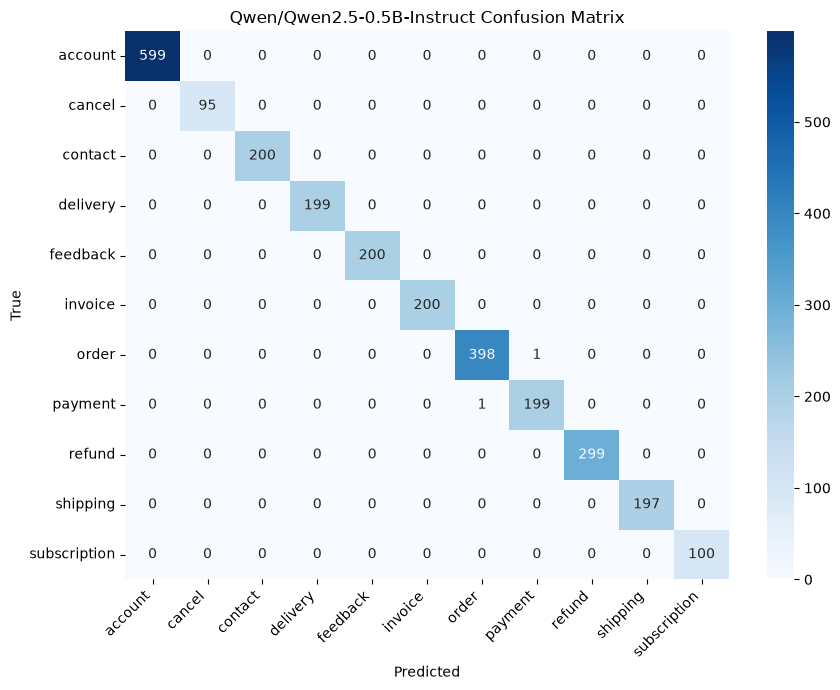

In [23]:
plot_confusion_matrix_heatmap(
    dec_labels, dec_predictions,
    [c.lower() for c in TARGET_CATEGORIES],
    title=f"{decoder_model_id} Confusion Matrix"
)


## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

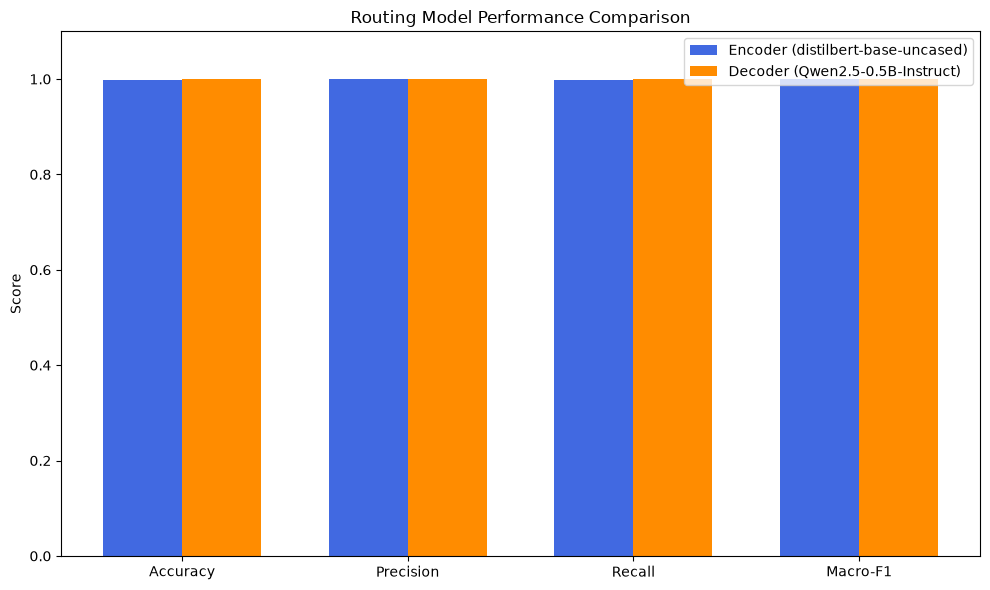

In [24]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width,
       label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width,
       label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


In [25]:
# Dedicated comparison table with measured values
comparison_table = pd.DataFrame({
    "Metric": [
        "Precision", "Recall", "Macro-F1", "Accuracy",
        "Peak GPU Memory (MB)", "Inference Latency (ms/query)"
    ],
    f"Encoder ({encoder_model_id})": [
        enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency
    ],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})": [
        dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency
    ],
})
comparison_table


,Metric,Encoder (distilbert/distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.999245,0.999318
1,Recall,0.998863,0.999318
2,Macro-F1,0.999051,0.999318
3,Accuracy,0.998884,0.999256
4,Peak GPU Memory (MB),937.773438,1715.868652
5,Inference Latency (ms/query),2.016549,132.973392


## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**

Based on our experiments, I recommend deploying the fine-tuned DistilBERT encoder (distilbert/distilbert-base-uncased) as the production router. While both architectures achieved virtually identical, near-perfect performance on the held-out test set (a macro-F1 of 0.9991 for DistilBERT versus 0.9993 for the Qwen2.5-0.5B + LoRA decoder), the encoder provides overwhelming operational efficiency. Beyond accuracy, the encoder's average inference latency of roughly 2.02 ms/query is over 65 times faster than the decoder's 132.97 ms/query, and it consumes roughly half the peak GPU memory (937.77 MB vs 1715.87 MB with 4-bit quantization), making it far cheaper to serve at the volume of an e-commerce support platform. The primary production risk of the encoder is silent misrouting of out-of-scope messages: a customer sending a casual greeting such as 'Hey, how's it going?' will still receive a confident (but wrong) routing label, because the model has no 'none-of-the-above' option. To monitor for this, I would log the softmax confidence score for every routing decision and alert on-call when the fraction of predictions below a 0.70 confidence threshold exceeds 2% of hourly traffic, triggering human review and potential retraining on newly collected edge cases.


## 9. Reflection

### Q1: On what transfers from pretraining

Pretraining provided both architectures with a comprehensive linguistic foundation—specifically syntax, semantics, contextual grammar, and word associations. Because the models were pretrained on massive amounts of web text, they already understood that phrases like "charged twice", "billing error", and "unauthorized transaction" share strong semantic proximity, enabling them to generalize effortlessly from our dataset across varied user phrasings.

However, pretraining provided zero awareness of ShopAssist AI's specific 11-category agent taxonomy. Fine-tuning was required from scratch to teach:
1. The Encoder: How to map general language representations into exact 11-class logits using a newly initialized classification head.
2. The Decoder: How to suppress its natural conversational verbosity, forcing it to generate only the exact uppercase category token (e.g., REFUND) followed immediately by an EOS token.

### Q2: On Handling Chit-Chat Queries

If a user sends an out-of-domain query like "Hey! How's it going?":

* Encoder (DistilBERT): Fails silently. Because the classification head uses a softmax over 11 fixed output nodes, it is mathematically forced to pick whichever category receives the highest relative probability, routing the user to a specialized agent who cannot assist.
* Decoder (Qwen2.5 + LoRA): Fails gracefully. As an open-ended text generator, it will likely output a conversational response (e.g., "Hello! How can I help you today?"). The downstream `normalize_decoder_output` parser will fail to match this to any valid 11-category string, triggering an unhandled exception or fallback label that can be cleanly caught by the application layer.

Production Mitigation:
To handle chit-chat robustly in production using the recommended encoder, we must implement a pre-routing guardrail. We can enforce a minimum softmax confidence threshold (e.g., 0.70). Any query falling below this threshold is flagged as out-of-domain and redirected to a general conversational bot or a human agent.